<a href="https://colab.research.google.com/github/prembhatx/Galaxy-Morphology-Classifier-CNN-/blob/main/SPARC_RAR_Scatter_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
up = files.upload()
print(list(up.keys()))

Saving RAR.mrt.txt to RAR.mrt.txt
Saving MassModels_Lelli2016c.mrt.txt to MassModels_Lelli2016c.mrt.txt
Saving SPARC_Lelli2016c.mrt.txt to SPARC_Lelli2016c.mrt.txt
['RAR.mrt.txt', 'MassModels_Lelli2016c.mrt.txt', 'SPARC_Lelli2016c.mrt.txt']


In [ ]:
f = "MassModels_Lelli2016c.mrt.txt"
L = open(f).read().splitlines()
k = max(i for i,l in enumerate(L) if l.startswith("---"))
print(len(L), k)
print("\n".join(L[:k+4]))

3416 24
Title: SPARC: Mass Models for 175 Disk Galaxies with Spitzer Photometry 
       and Accurate Rotation Curves 
Authors: Lelli F., McGaugh S.S., Schombert J.M.
Table: Mass Models
Byte-by-byte Description of file: datafile2.txt
--------------------------------------------------------------------------------
   Bytes Format Units        Label   Explanations
--------------------------------------------------------------------------------
   1- 11 A11    ---          ID      Galaxy identifier
  13- 18 F6.2   Mpc          D       Assumed distance
  20- 25 F6.2   kpc          R       Galactocentric radius
  27- 32 F6.2   km/s         Vobs    Observed circular velocity
  34- 38 F5.2   km/s       e_Vobs    Uncertainty in Vobs (1)
  40- 45 F6.2   km/s         Vgas    Gas velocity contribution (2)
  47- 52 F6.2   km/s         Vdisk   Disk velocity contribution (3)
  54- 59 F6.2   km/s         Vbul    Bulge velocity contribution (3)
  61- 67 F7.2   solLum/pc2   SBdisk  Disk surface brightne

(3391, 10) 175


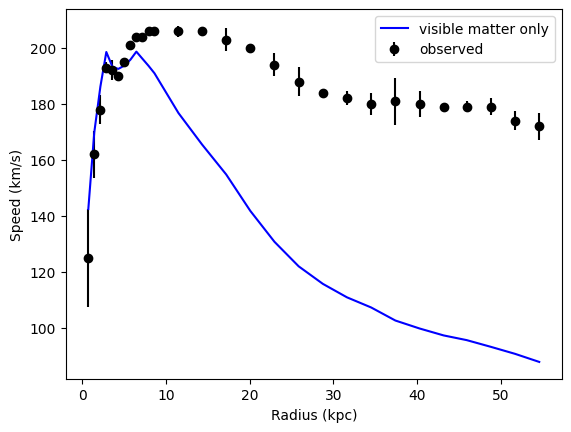

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
cols = ["ID","D","R","Vobs","e_Vobs","Vgas","Vdisk","Vbul","SBdisk","SBbul"]
mm = pd.read_csv("MassModels_Lelli2016c.mrt.txt", skiprows=25, sep=r"\s+", names=cols)
print(mm.shape, mm.ID.nunique())
g = mm[mm.ID=="NGC5055"]
vbar = np.sqrt(np.clip(g.Vgas*abs(g.Vgas) + 0.5*g.Vdisk*abs(g.Vdisk) + 0.7*g.Vbul*abs(g.Vbul), 0, None))
plt.errorbar(g.R, g.Vobs, yerr=g.e_Vobs, fmt="ko", label="observed")
plt.plot(g.R, vbar, "b-", label="visible matter only")
plt.xlabel("Radius (kpc)")
plt.ylabel("Speed (km/s)")
plt.legend()
plt.savefig("rotation_curve_NGC5055.png", dpi=150)
plt.show()

3389


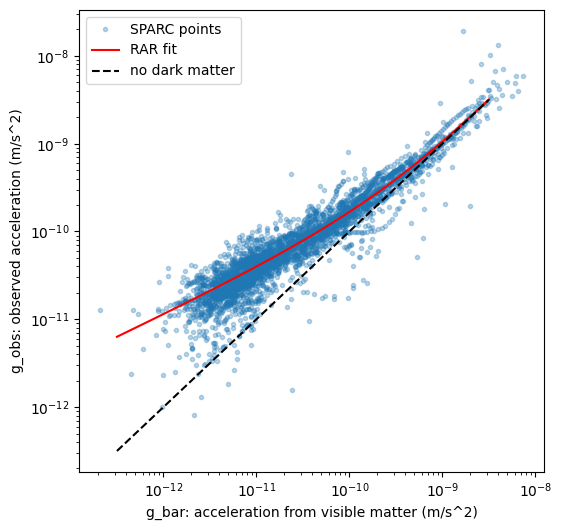

In [ ]:
kpc = 3.0857e19
mm["gobs"] = (mm.Vobs*1e3)**2/(mm.R*kpc)
vb2 = mm.Vgas*abs(mm.Vgas) + 0.5*mm.Vdisk*abs(mm.Vdisk) + 0.7*mm.Vbul*abs(mm.Vbul)
mm["gbar"] = (vb2*1e6)/(mm.R*kpc)
d = mm[(mm.gbar>0)&(mm.gobs>0)]
print(len(d))
x = np.logspace(-12.5,-8.5,200)
fit = x/(1-np.exp(-np.sqrt(x/1.2e-10)))
plt.figure(figsize=(6,6))
plt.loglog(d.gbar, d.gobs, ".", alpha=0.3, label="SPARC points")
plt.loglog(x, fit, "r-", label="RAR fit")
plt.loglog(x, x, "k--", label="no dark matter")
plt.xlabel("g_bar: acceleration from visible matter (m/s^2)")
plt.ylabel("g_obs: observed acceleration (m/s^2)")
plt.legend()
plt.savefig("rar_plot.png", dpi=150)
plt.show()

overall scatter (dex): 0.196 mean: -0.034


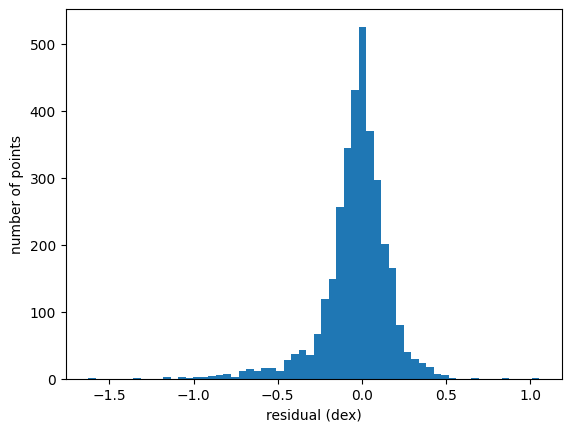

(175, 18)
(175, 22)
T       -0.23
D        0.08
Inc     -0.03
L36      0.16
Reff     0.08
SBeff    0.22
Rdisk    0.11
MHI      0.18
Vflat    0.35
Q       -0.41
mean     1.00
Name: mean, dtype: float64


In [ ]:
res = np.log10(d.gobs) - np.log10(d.gbar/(1-np.exp(-np.sqrt(d.gbar/1.2e-10))))
d = d.assign(res=res)
print("overall scatter (dex):", round(d.res.std(),3), "mean:", round(d.res.mean(),3))
plt.hist(d.res, bins=60)
plt.xlabel("residual (dex)")
plt.ylabel("number of points")
plt.savefig("rar_residual_hist.png", dpi=150)
plt.show()
gal = d.groupby("ID").res.agg(["mean","std","count"]).reset_index()
L = open("SPARC_Lelli2016c.mrt.txt").read().splitlines()
k = max(i for i,l in enumerate(L) if l.startswith("---"))
c1 = ["Galaxy","T","D","e_D","f_D","Inc","e_Inc","L36","e_L36","Reff","SBeff","Rdisk","SBdisk","MHI","RHI","Vflat","e_Vflat","Q"]
t1 = pd.read_csv("SPARC_Lelli2016c.mrt.txt", skiprows=k+1, sep=r"\s+", names=c1, usecols=range(18))
print(t1.shape)
m = gal.merge(t1, left_on="ID", right_on="Galaxy")
print(m.shape)
cols = ["T","D","Inc","L36","Reff","SBeff","Rdisk","MHI","Vflat","Q"]
print(m[cols+["mean"]].corr(method="spearman")["mean"].round(2))

In [ ]:
from scipy.stats import spearmanr
cols2 = ["T","Inc","L36","SBeff","MHI","Vflat","Q"]
tab = lambda df: pd.DataFrame([(c, *spearmanr(df[c], df["mean"])) for c in cols2], columns=["property","rho","p"]).round(3)
m2 = m[m.Vflat>0]
print("Vflat>0:", len(m2))
print(tab(m2))
m3 = m[(m.Q<3)&(m.Inc>=30)&(m.Vflat>0)]
print("Q<3, Inc>=30, Vflat>0:", len(m3))
print(tab(m3))

Vflat>0: 135
  property    rho      p
0        T -0.129  0.137
1      Inc -0.075  0.388
2      L36  0.088  0.312
3    SBeff  0.111  0.202
4      MHI  0.045  0.606
5    Vflat  0.260  0.002
6        Q -0.317  0.000
Q<3, Inc>=30, Vflat>0: 123
  property    rho      p
0        T -0.137  0.131
1      Inc -0.079  0.388
2      L36  0.084  0.356
3    SBeff  0.100  0.272
4      MHI  0.022  0.807
5    Vflat  0.230  0.011
6        Q -0.253  0.005
